### Final Modelling Notebook

In [ ]:
# comments by Ashley Hui, unless specificed otherwise, markdown is by the programmer's name in their indicated section

In [ ]:
# start - Eddie Nguyen
# grab our preprocessed data from custom function, splits it to train and test, prepares it to be used for modelling 
# show the data to double check

In [ ]:
from unittest.mock import inplace

from statsmodels.graphics.gofplots import qqplot

from src.Preprocessing import get_preprocessed_data

X_train, X_test, y_train, y_test = get_preprocessed_data(output_as='random_split')

In [ ]:

X_train.head()

,Latitude,Longitude,PostalCode,AttachedGarageYN,BathroomsTotalInteger,BedroomsTotal,FireplaceYN,GarageSpaces,LivingArea,MainLevelBedrooms,...,Flooring_Vinyl,Flooring_Laminate,Flooring_SeeRemarks,Flooring_Wood,Flooring_Brick,Flooring_Bamboo,Levels_ThreeOrMore,Levels_Two,Levels_One,Levels_MultiSplit
38274,-0.321713,0.118533,0.230263,0,0.0,1.0,0,0.0,-0.016268,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
13971,-0.420112,0.191335,0.140550,0,1.0,1.0,0,0.0,0.348325,-2.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
5891,-0.439796,0.063116,0.160287,0,2.0,0.0,0,0.0,1.378947,-3.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
36023,-0.387666,0.908424,-0.084928,0,0.0,0.0,0,0.0,-0.430622,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
75410,-0.905605,0.477600,-0.218900,0,1.0,0.0,0,0.0,0.056459,-3.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,-1.0,0.0


In [ ]:
# looped through missing values, stored cols with less than 100 na vals
# calculated percent of missing values per col
# show the rates

In [ ]:
cols_with_na = []
for col in X_train.columns:
    na_count = X_train[col].isna().sum()
    print(f'{col}: {na_count} NAs')
    if na_count < 100:
        cols_with_na.append(col)



Latitude: 0 NAs
Longitude: 0 NAs
PostalCode: 0 NAs
AttachedGarageYN: 0 NAs
BathroomsTotalInteger: 0 NAs
BedroomsTotal: 0 NAs
FireplaceYN: 0 NAs
GarageSpaces: 0 NAs
LivingArea: 0 NAs
MainLevelBedrooms: 0 NAs
NewConstructionYN: 0 NAs
ParkingTotal: 0 NAs
PoolPrivateYN: 0 NAs
Stories: 0 NAs
ViewYN: 0 NAs
YearBuilt: 0 NAs
LotSizeAcres: 0 NAs
LotSizeArea: 0 NAs
LotSizeSquareFeet: 0 NAs
AssociationFee: 0 NAs
DaysOnMarket: 0 NAs
sin_closed_date: 0 NAs
Flooring_Concrete: 0 NAs
Flooring_Tile: 0 NAs
Flooring_Stone: 0 NAs
Flooring_Carpet: 0 NAs
Flooring_Vinyl: 0 NAs
Flooring_Laminate: 0 NAs
Flooring_SeeRemarks: 0 NAs
Flooring_Wood: 0 NAs
Flooring_Brick: 0 NAs
Flooring_Bamboo: 0 NAs
Levels_ThreeOrMore: 0 NAs
Levels_Two: 0 NAs
Levels_One: 0 NAs
Levels_MultiSplit: 0 NAs


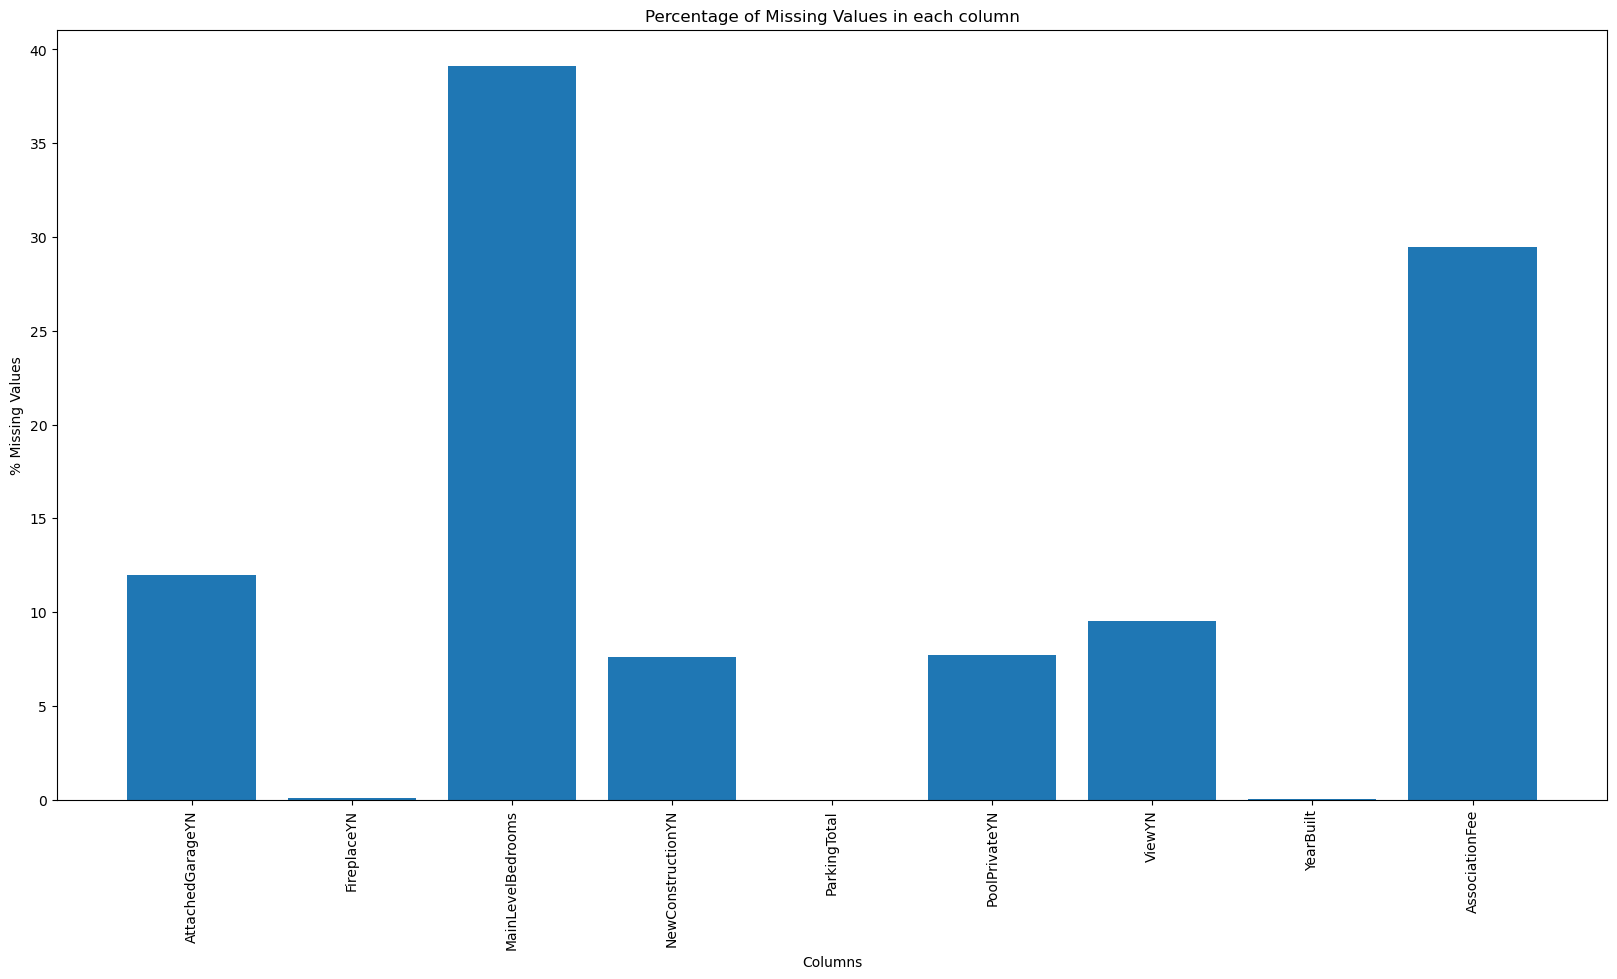

In [ ]:

import pandas as pd
import matplotlib.pyplot as plt

def column_na_plot(df: pd.DataFrame):
    is_na = []
    data = df.copy()
    for column in data.columns:
        is_na_perc = data[column].isna().sum() * 100 / len(data[column])
        if is_na_perc > 0:
            is_na.append( is_na_perc )
        else:
            data.drop(column, axis=1, inplace=True)
    plt.figure(figsize = (20,10))
    plt.bar(x=data.columns, height=is_na)
    plt.xticks(rotation=90)
    plt.xlabel('Columns')
    plt.ylabel('% Missing Values')
    plt.title('Percentage of Missing Values in each column')
    plt.show()

column_na_plot(X_train)

### Assume values for missing value of YN columns are N

In [ ]:
# imputed missing vals w mode (most common val)

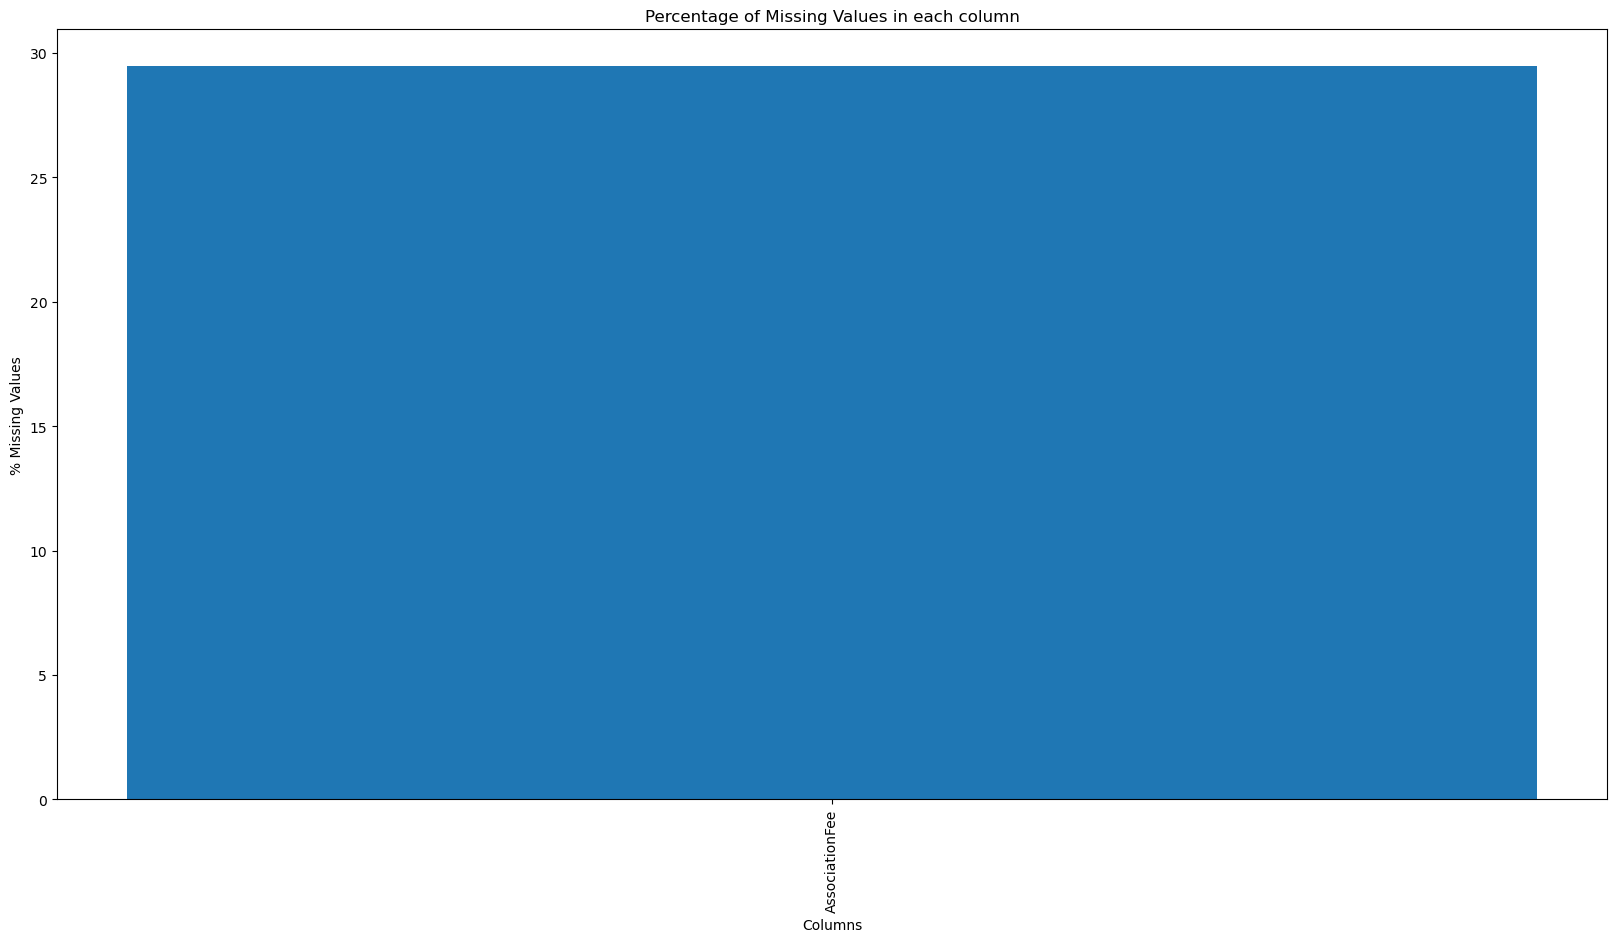

In [ ]:


from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="most_frequent")
cols_to_impute = ['AttachedGarageYN', 'FireplaceYN', 'NewConstructionYN', 'PoolPrivateYN', 'ViewYN', 'ParkingTotal', 'YearBuilt', 'MainLevelBedrooms']

X_train[cols_to_impute] = imputer.fit_transform(X_train[cols_to_impute])
X_test[cols_to_impute] = imputer.fit_transform(X_test[cols_to_impute])

column_na_plot(X_train)

## Assume houses with missing HOA are houses with no HOA

In [ ]:

def fill_zeros(x):
    if pd.isna(x):
        return 0
    else:
        return x

X_train['AssociationFee'] = X_train['AssociationFee'].apply(fill_zeros)
X_test['AssociationFee'] = X_test['AssociationFee'].apply(fill_zeros)

In [ ]:

cols_with_na = []
for col in X_train.columns:
    na_count = X_train[col].isna().sum()
    print(f'{col}: {na_count} NAs')
    if na_count < 100:
        cols_with_na.append(col)

Latitude: 0 NAs
Longitude: 0 NAs
PostalCode: 0 NAs
AttachedGarageYN: 0 NAs
BathroomsTotalInteger: 0 NAs
BedroomsTotal: 0 NAs
FireplaceYN: 0 NAs
GarageSpaces: 0 NAs
LivingArea: 0 NAs
MainLevelBedrooms: 0 NAs
NewConstructionYN: 0 NAs
ParkingTotal: 0 NAs
PoolPrivateYN: 0 NAs
Stories: 0 NAs
ViewYN: 0 NAs
YearBuilt: 0 NAs
LotSizeAcres: 0 NAs
LotSizeArea: 0 NAs
LotSizeSquareFeet: 0 NAs
AssociationFee: 0 NAs
DaysOnMarket: 0 NAs
sin_closed_date: 0 NAs
Flooring_SeeRemarks: 0 NAs
Flooring_Tile: 0 NAs
Flooring_Stone: 0 NAs
Flooring_Vinyl: 0 NAs
Flooring_Bamboo: 0 NAs
Flooring_Brick: 0 NAs
Flooring_Carpet: 0 NAs
Flooring_Wood: 0 NAs
Flooring_Laminate: 0 NAs
Flooring_Concrete: 0 NAs
Levels_Two: 0 NAs
Levels_One: 0 NAs
Levels_MultiSplit: 0 NAs
Levels_ThreeOrMore: 0 NAs


# Evaluation with Random Forest

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

rf = RandomForestRegressor(n_estimators=100, max_depth=20)

result = rf.fit(X=X_train, y=y_train)
result

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [ ]:
# predict from test data, created metric to catch typical % of error, (median absolute percent error)
# checks to see how accurate model is 
# use cross-validation to check r2 for goodness of fit and absolute error (mae)
# convert log scaled predications to actual price to see real world percent error

In [ ]:


y_pred = rf.predict(X_test)

from sklearn.metrics import r2_score, make_scorer
from sklearn.model_selection import cross_validate
import numpy as np

def mdape(y_pred, y_test):
    error = abs(y_test - y_pred)
    return np.median((error * 100) / y_test)

mdape_score = make_scorer(mdape, greater_is_better=False)

r2_result = cross_validate(rf, X=X_test, y=y_test, scoring=['r2', 'neg_median_absolute_error'], cv=5)
mdape_result = mdape(y_pred, y_test)

# print(f'MdAPE: {mdape_result}%')
print(f'R2: {r2_result}')

MdAPE: 0.5913310389333973%
R2: {'fit_time': array([4.37640905, 4.37325597, 4.32907009, 4.38217902, 4.25227904]), 'score_time': array([0.03671193, 0.03175712, 0.03176308, 0.03226209, 0.03058887]), 'test_r2': array([0.80698431, 0.84153681, 0.84973397, 0.85171412, 0.79432904]), 'test_neg_median_absolute_error': array([-0.10988931, -0.09386972, -0.09600795, -0.09670434, -0.11147099])}


In [ ]:


def real_world_mdape(y_pred_log, y_test_log):
    # Convert back to original scale (e.g., Dollars)
    y_pred_actual = np.exp(y_pred_log)
    y_test_actual = np.exp(y_test_log)

    # Calculate percentage error on the actual values
    error = np.abs(y_test_actual - y_pred_actual)
    return np.median(error / y_test_actual) * 100

# Run this on your results
actual_mdape = real_world_mdape(y_pred, y_test)
print(f'Actual Price MdAPE: {actual_mdape:.2f}%')

Actual Price MdAPE: 8.09%


In [ ]:
# show out residuals on plot
# ideally should look like a straight diagonal line
# looking for bias and heteroscedasticity

Text(0.5, 0, 'residual')

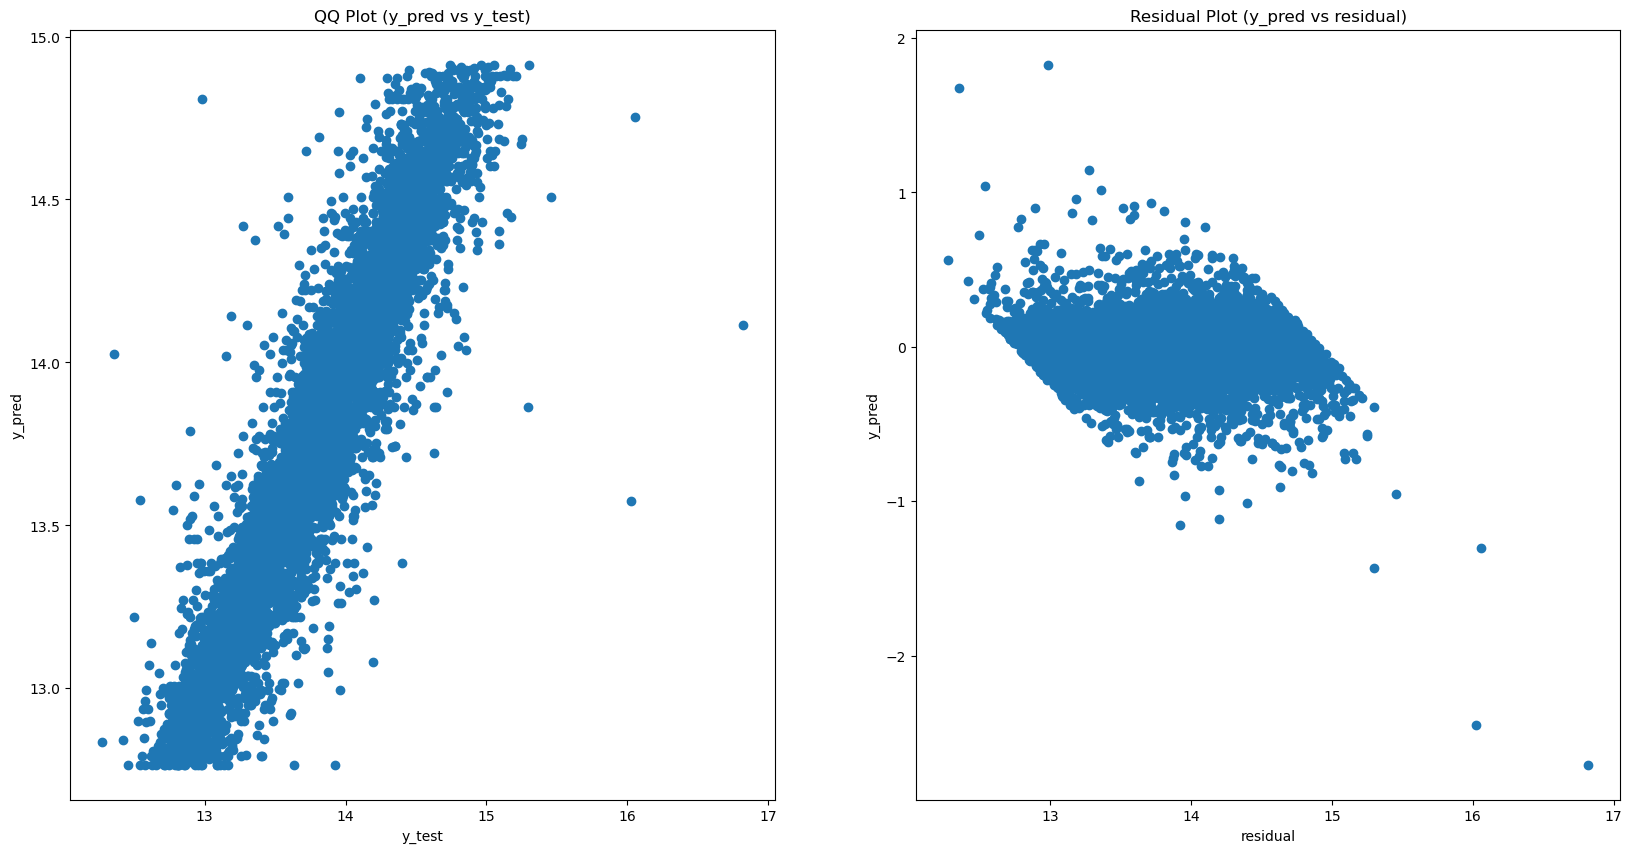

In [ ]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(20,10))

axs[0].scatter(x=y_pred, y=y_test)
axs[0].set_title("QQ Plot (y_pred vs y_test)")
axs[0].set_ylabel("y_pred")
axs[0].set_xlabel("y_test")


axs[1].scatter(x=y_pred, y=y_test-y_pred)
axs[1].set_title("Residual Plot (y_pred vs residual)")
axs[1].set_ylabel("y")
axs[1].set_xlabel("residual")

In [ ]:
# added shap to show feature importance per prediction
# look at most important features

In [ ]:
pip install shap
import shap

explainer = shap.TreeExplainer(rf)
shap_val = explainer.shap_values(X_test[:1000])
shap.summary_plot

ModuleNotFoundError: No module named 'shap'

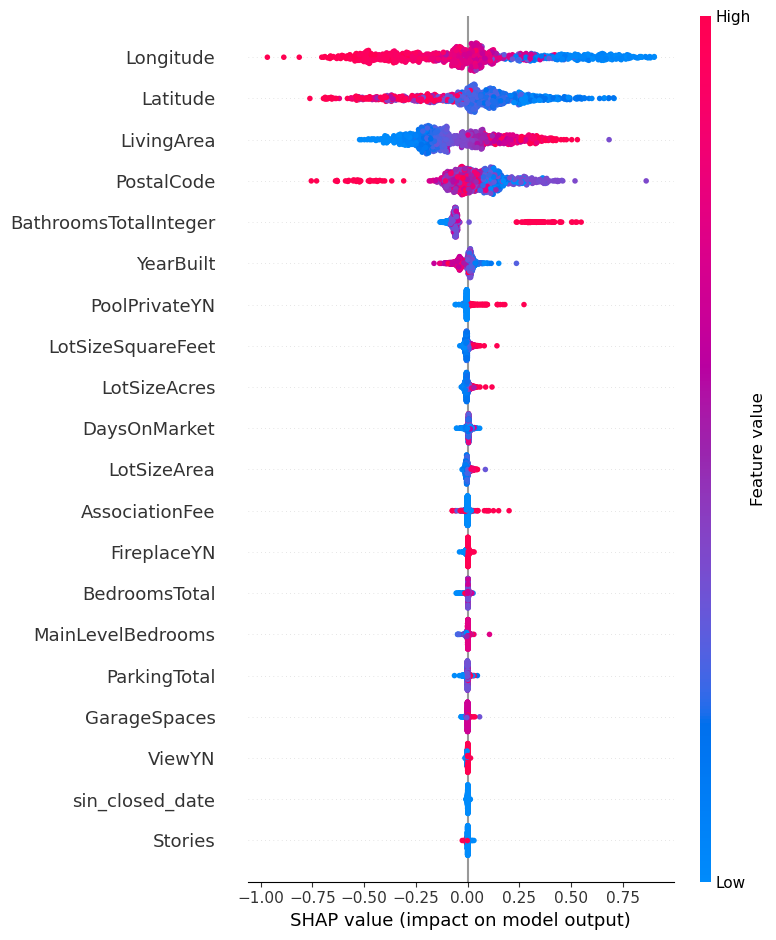

In [ ]:

shap.summary_plot(shap_val, X_test[:1000])

### Geo info seems to have the most impact on log_price

In [ ]:
# reloaded data and dropped cols that aren't useful

In [ ]:

from src.Preprocessing import get_unprocessed_data

df = get_unprocessed_data()
df['Flooring'].unique()

Retrieved 186296 rows of data from the database.


<StringArray>
[                                     nan,
                        'Carpet,Laminate',
                            'Carpet,Tile',
                       'Carpet,Tile,Wood',
                          'Laminate,Tile',
                               'Laminate',
                           'Carpet,Vinyl',
                 'Carpet,Tile,Vinyl,Wood',
                                   'Tile',
                                   'Wood',
 ...
  'Carpet,Laminate,Stone,Tile,Vinyl,Wood',
                 'Bamboo,SeeRemarks,Wood',
       'Carpet,Laminate,Stone,Vinyl,Wood',
                 'Bamboo,Tile,Vinyl,Wood',
        'Bamboo,Laminate,Stone,Tile,Wood',
           'Brick,Carpet,Stone,Tile,Wood',
  'Carpet,Laminate,SeeRemarks,Stone,Tile',
 'Concrete,Laminate,SeeRemarks,Tile,Wood',
  'Carpet,Laminate,SeeRemarks,Stone,Wood',
         'Concrete,SeeRemarks,Tile,Vinyl']
Length: 283, dtype: str

In [ ]:

from src.Preprocessing import get_preprocessed_data

X_train, X_test, y_train, y_test = get_preprocessed_data(output_as='random_split')

Creating database directory...
Data folders created.
Database file found. Initializing connection...
No new CSVs to import to the database. Returning connection...
Connection initialized.
Retrieved 186296 rows of data from the database.
Processing 186296 rows of data.
Finished parsing PostalCode.
Finished cyclical encoding CloseDate.
Finished transforming abs(DaysOnMarket).
Finished transforming log(ClosePrice).
Finished transforming log(lastPriceByZip).
Found pre-trained encoder model for Flooring. Returning artifact...
Encoding Flooring...
Encoded Flooring with MultiLabelBinarizer.
Finished de-stacking and encoding Flooring.
Found pre-trained encoder model for Levels. Returning artifact...
Encoding Levels...
Encoded Levels with MultiLabelBinarizer.
Finished de-stacking and encoding Levels.
Finished feature engineering.
Found pre-trained imputer model for YearBuilt. Returning artifact...
Finished imputation for YearBuilt.
Found pre-trained imputer model for BedroomsTotal. Returning ar

In [ ]:
X_train.info()

<class 'pandas.DataFrame'>
Index: 149022 entries, 174346 to 121958
Data columns (total 38 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   Latitude               149022 non-null  float64       
 1   Longitude              149022 non-null  float64       
 2   PostalCode             149022 non-null  float64       
 3   AttachedGarageYN       149022 non-null  float64       
 4   BathroomsTotalInteger  149022 non-null  float64       
 5   BedroomsTotal          149022 non-null  float64       
 6   FireplaceYN            149022 non-null  float64       
 7   GarageSpaces           149022 non-null  float64       
 8   LivingArea             149022 non-null  float64       
 9   MainLevelBedrooms      149022 non-null  float64       
 10  NewConstructionYN      149022 non-null  float64       
 11  ParkingTotal           149022 non-null  float64       
 12  PoolPrivateYN          149022 non-null  float64       


In [ ]:
X_train.drop("ReadDate", axis=1, inplace=True)
X_test.drop("ReadDate", axis=1, inplace=True)

In [ ]:
# used yellow brick to plot residuals to check normality
# and model fit quality

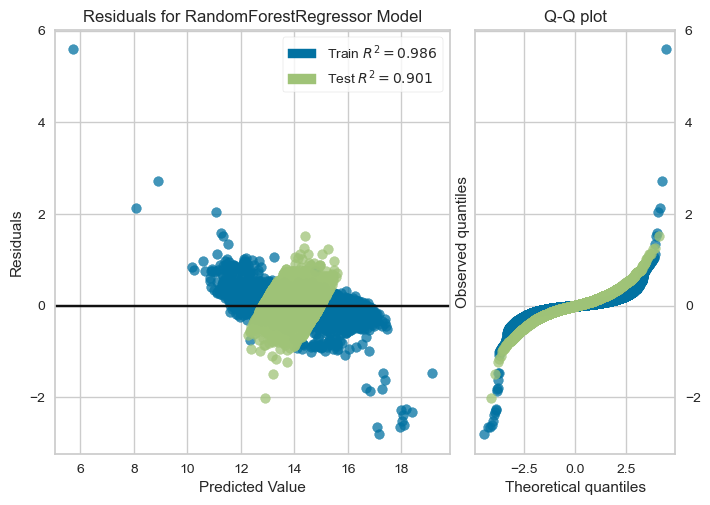

<Axes: title={'center': 'Residuals for RandomForestRegressor Model'}, xlabel='Predicted Value', ylabel='Residuals'>

In [ ]:
from yellowbrick.regressor import ResidualsPlot
from sklearn.ensemble import RandomForestRegressor

# Huiyu's best RF model from GridSearchCV
rf = RandomForestRegressor(n_estimators=200, min_samples_split=2, min_samples_leaf=1, max_features='sqrt')

visualizer = ResidualsPlot(rf, qqplot=True, hist=False)
visualizer.fit(X_train, y_train)
visualizer.score(X_test, y_test)
visualizer.show()


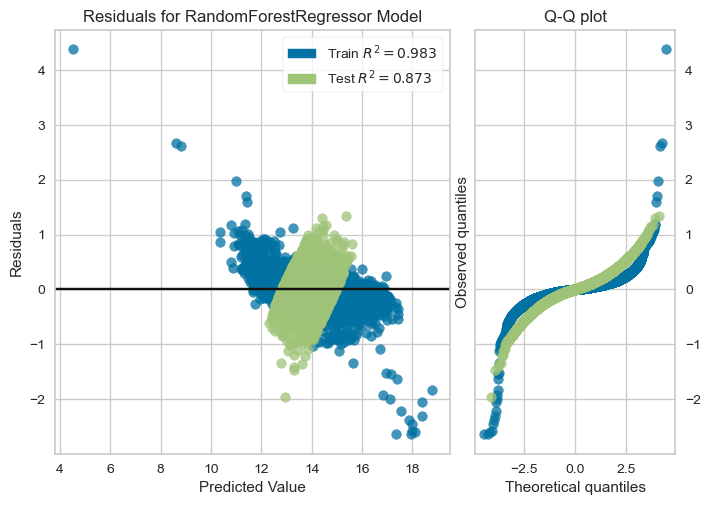

<Axes: title={'center': 'Residuals for RandomForestRegressor Model'}, xlabel='Predicted Value', ylabel='Residuals'>

In [ ]:
from yellowbrick.regressor import ResidualsPlot
from sklearn.ensemble import RandomForestRegressor

# Huiyu's best RF model from GridSearchCV
rf = RandomForestRegressor(n_estimators=200, min_samples_split=2, min_samples_leaf=1, max_features='sqrt')

visualizer = ResidualsPlot(rf, qqplot=True, hist=False)
visualizer.fit(X_train, y_train)
visualizer.score(X_test, y_test)
visualizer.show()


# Model Evaluation using metrics (Training set)

In [ ]:
from validation import evaluate

rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
evaluate(y_pred=y_pred, y_test=y_test)

R2: 0.8581
R2 (log): 0.9007
MdAPE (log-scale): 0.57%
MdAPE (dollar-scale): 7.76%


C:\Users\Eddie Nguyen\.conda\envs\IDX\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


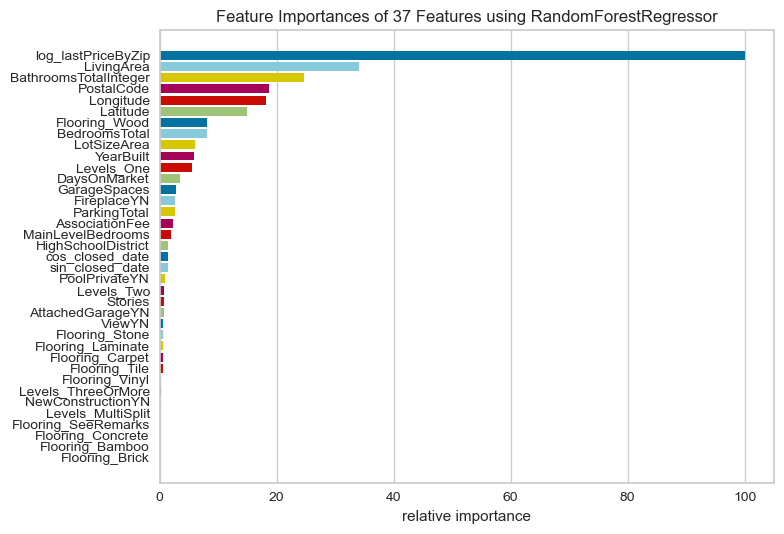

<Axes: title={'center': 'Feature Importances of 37 Features using RandomForestRegressor'}, xlabel='relative importance'>

In [ ]:
from yellowbrick.model_selection import FeatureImportances
visualizer = FeatureImportances(rf)
visualizer.fit(X_train, y_train)
visualizer.show()


In [ ]:
# converted categorical var (postal code) to numeric to be used in model
# compared each feature's importance

C:\Users\Eddie Nguyen\.conda\envs\IDX\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


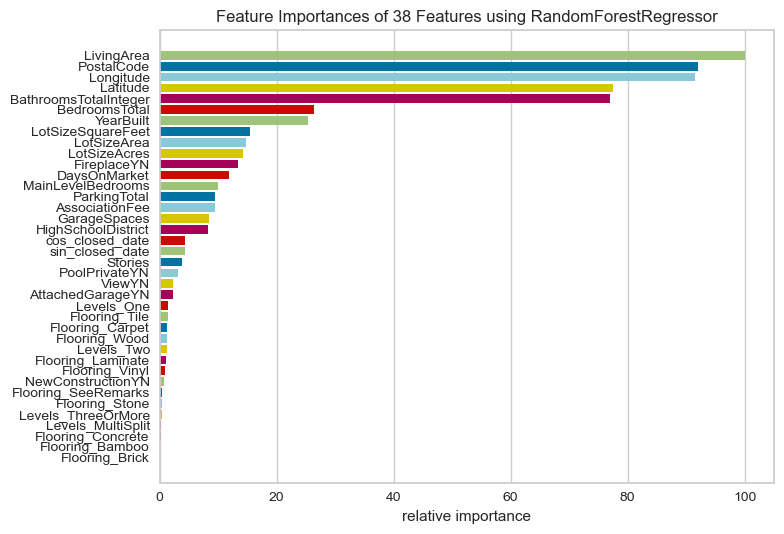

<Axes: title={'center': 'Feature Importances of 38 Features using RandomForestRegressor'}, xlabel='relative importance'>

In [ ]:
from sklearn.preprocessing import TargetEncoder

encoder = TargetEncoder(smooth='auto', cv=5)

X_train['PostalCode'] = encoder.fit_transform(X_train[['PostalCode']], y_train)
X_test['PostalCode'] = encoder.fit_transform(X_test[['PostalCode']], y_test)

visualizer = FeatureImportances(rf)
visualizer.fit(X_train, y_train)
visualizer.show()

In [ ]:
# re-calculated  model again after encoding, checked the residuals 

C:\Users\Eddie Nguyen\.conda\envs\IDX\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


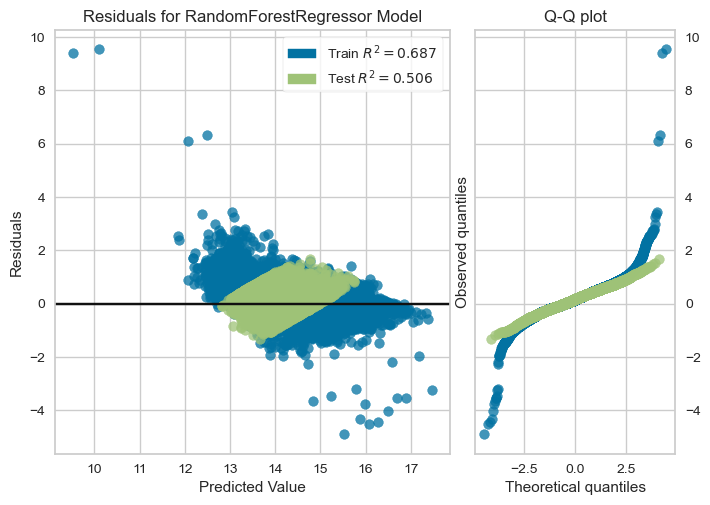

<Axes: title={'center': 'Residuals for RandomForestRegressor Model'}, xlabel='Predicted Value', ylabel='Residuals'>

In [ ]:
visualizer = ResidualsPlot(rf, qqplot=True, hist=False)
visualizer.fit(X_train, y_train)
visualizer.score(X_test, y_test)
visualizer.show()

# Model Evaluation (Evaluation set Jan 26)


In [ ]:
#loaded evaluation data, make predications, plot them

In [ ]:
from Preprocessing import get_eval_data

eval_df = get_eval_data()
target = eval_df['log_price']
eval_df.drop(columns=['log_price'], inplace=True)

Creating database directory...
Data folders created.
Database file found. Initializing connection...
No new CSVs to import to the database. Returning connection...
Connection initialized.
Retrieved 8542 rows of data from the database.
Processing 8542 rows of data.
Finished parsing PostalCode.
Finished cyclical encoding CloseDate.
Finished transforming abs(DaysOnMarket).
Finished transforming log(ClosePrice).
Finished transforming log(lastPriceByZip).
Found pre-trained encoder model for Flooring. Returning artifact...
Encoding Flooring...
Encoded Flooring with MultiLabelBinarizer.
Finished de-stacking and encoding Flooring.
Found pre-trained encoder model for Levels. Returning artifact...
Encoding Levels...
Encoded Levels with MultiLabelBinarizer.
Finished de-stacking and encoding Levels.
Finished feature engineering.
Found pre-trained imputer model for YearBuilt. Returning artifact...
Finished imputation for YearBuilt.
Found pre-trained imputer model for BedroomsTotal. Returning artifa

In [ ]:
from validation import get_eval_plots, evaluate
eval_df.drop(columns=['ReadDate'], inplace=True)
y_pred = rf.predict(eval_df)
evaluate(y_pred=y_pred, y_test=target)

R2: 0.0129
R2 (log): 0.8929
MdAPE (log-scale): 0.65%
MdAPE (dollar-scale): 8.95%


C:\Users\Eddie Nguyen\AppData\Local\Temp\ipykernel_59248\3684330063.py:1: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  get_eval_plots(y_pred, target).show()


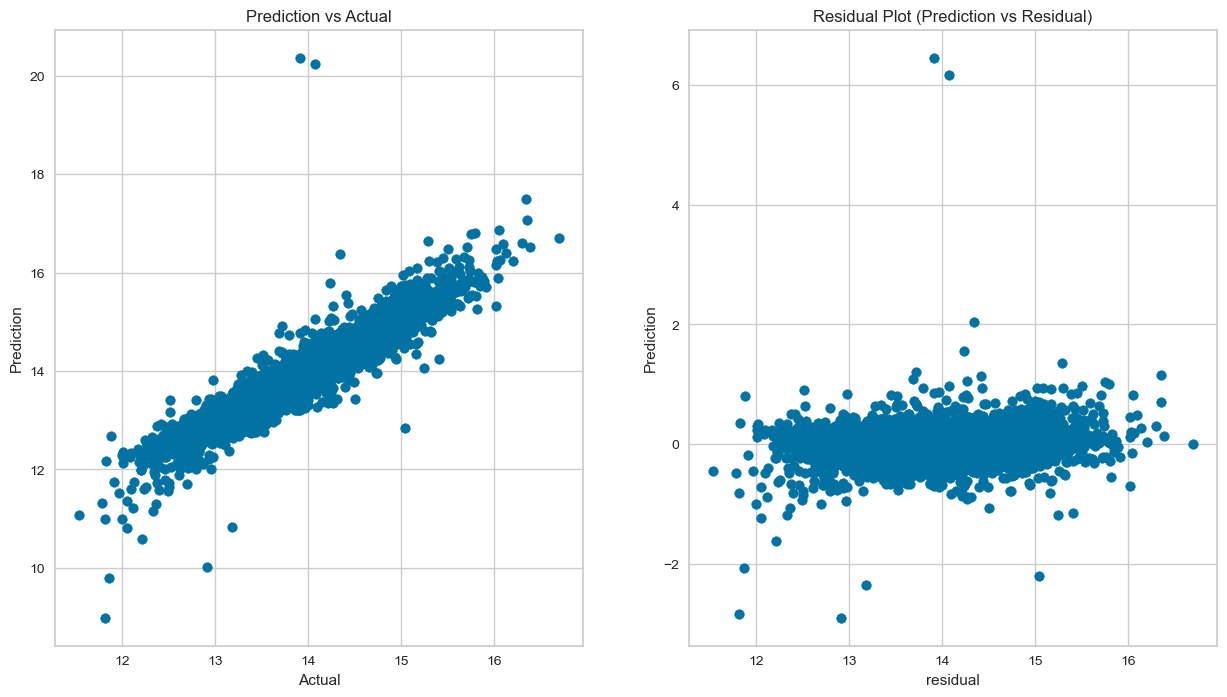

In [ ]:
get_eval_plots(y_pred, target).show()

# Model Performance

## 1. Predictive Accuracy
The model demonstrates strong linear alignment across the primary target range ($12$ to $16$ on the log scale). The tight grouping in the $y_{pred}$ vs. $y_{test}$ plot indicates that the current feature engineering has successfully captured the underlying signal of the dataset.
## 2. Residual Analysis
### Central Tendency:
The majority of residuals are centered around zero with constant variance (homoscedasticity) within the "trust zone," suggesting the model is unbiased for the bulk of the data.
### Outlier Detection:
Two significant outliers were identified with high positive residuals. These represent extreme cases where the model significantly under-predicted the target. These can be addressed via input clipping or robust filtering during the preprocessing stage.

In [ ]:
X_train.columns

Index(['Latitude', 'Longitude', 'PostalCode', 'AttachedGarageYN',
       'BathroomsTotalInteger', 'BedroomsTotal', 'FireplaceYN', 'GarageSpaces',
       'LivingArea', 'MainLevelBedrooms', 'NewConstructionYN', 'ParkingTotal',
       'PoolPrivateYN', 'Stories', 'ViewYN', 'YearBuilt', 'HighSchoolDistrict',
       'LotSizeAcres', 'LotSizeArea', 'LotSizeSquareFeet', 'AssociationFee',
       'DaysOnMarket', 'sin_closed_date', 'cos_closed_date', 'Flooring_Bamboo',
       'Flooring_Brick', 'Flooring_Carpet', 'Flooring_Concrete',
       'Flooring_Laminate', 'Flooring_SeeRemarks', 'Flooring_Stone',
       'Flooring_Tile', 'Flooring_Vinyl', 'Flooring_Wood', 'Levels_MultiSplit',
       'Levels_One', 'Levels_ThreeOrMore', 'Levels_Two'],
      dtype='str')

In [ ]:
from Preprocessing import get_preprocessed_data
import numpy as np
import pandas as pd

df = get_preprocessed_data(output_as='df')

Creating database directory...
Data folders created.
Database file found. Initializing connection...
No new CSVs to import to the database. Returning connection...
Connection initialized.
Retrieved 186296 rows of data from the database.
Processing 186296 rows of data.
Finished parsing PostalCode.
Finished cyclical encoding CloseDate.
Finished transforming abs(DaysOnMarket).
Finished transforming log(ClosePrice).
Found pre-trained encoder model for Flooring. Returning artifact...
Encoding Flooring...
Encoded Flooring with MultiLabelBinarizer.
Finished de-stacking and encoding Flooring.
Found pre-trained encoder model for Levels. Returning artifact...
Encoding Levels...
Encoded Levels with MultiLabelBinarizer.
Finished de-stacking and encoding Levels.
Finished feature engineering.
Found pre-trained imputer model for YearBuilt. Returning artifact...
Finished imputation for YearBuilt.
Found pre-trained imputer model for BedroomsTotal. Returning artifact...
Finished imputation for BedroomsT

In [ ]:
#calculates average price per zip code over time, use previous val using lag, create a new feature
#using lag will prevent data leakage, using past info only

In [ ]:

postal_code_agg = df.groupby(['PostalCode', 'ReadDate'])['log_price'].mean()
# original_agg.sort_values(['PostalCode', 'ReadDate'], inplace=True, ascending=False)
for zipcode in df.PostalCode.unique():
    postal_code_agg[zipcode] = postal_code_agg[zipcode].shift(1, fill_value=0)

postal_code_agg = postal_code_agg.reset_index()
postal_code_agg.rename(columns={"log_price": "lastPriceByZip"}, inplace=True)

In [ ]:
pd.merge(df, postal_code_agg, how='left', on=['PostalCode', 'ReadDate'])

,Latitude,Longitude,PostalCode,AttachedGarageYN,BathroomsTotalInteger,BedroomsTotal,FireplaceYN,GarageSpaces,LivingArea,MainLevelBedrooms,...,Flooring_SeeRemarks,Flooring_Stone,Flooring_Tile,Flooring_Vinyl,Flooring_Wood,Levels_MultiSplit,Levels_One,Levels_ThreeOrMore,Levels_Two,lastPriceByZip
0,37.439456,-122.233180,94062.0,0.0,6.0,4.0,1.0,2.0,4636.0,3.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,14.706186
1,37.878010,-121.868460,94517.0,1.0,1.0,2.0,0.0,0.0,1600.0,3.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,13.773810
2,34.083995,-118.066006,91770.0,0.0,1.0,2.0,1.0,2.0,937.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,13.715053
3,34.275406,-118.415425,91331.0,1.0,1.0,3.0,0.0,2.0,1267.0,3.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,13.457325
4,33.700868,-117.978506,92708.0,1.0,4.0,4.0,0.0,2.0,1920.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,14.197873
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
186273,33.657426,-117.999922,92648.0,0.0,1.0,1.0,0.0,0.0,600.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,14.591342
186274,39.921866,-122.183747,96021.0,0.0,2.0,3.0,0.0,0.0,1825.0,3.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,13.704579
186275,33.941069,-116.976432,92223.0,0.0,1.0,2.0,0.0,0.0,876.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,13.177191
186276,33.305878,-117.190820,92003.0,1.0,5.0,3.0,0.0,4.0,7865.0,3.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,14.326399


In [ ]:
# end - Eddie Nguyen 

In [ ]:
# continued to train, test. and fine tune models 

In [ ]:
# start - Huiyu Yie (Elsa)

#### Train baseline models 

In this step, I chose the following models as the baseline starting point:
- Linear Regression
- Ridge Regression
- Random Forest
- XGBoost

In [ ]:

# Linear Regression baseline
lin_model = LinearRegression()
lin_model.fit(X_train_model, y_train)
lin_pred = lin_model.predict(X_test_model)
evaluate_model("Linear Regression", y_test, lin_pred)

# Ridge Regression baseline
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_model, y_train)
ridge_pred = ridge_model.predict(X_test_model)
evaluate_model("Ridge Regression", y_test, ridge_pred)

# Random Forest baseline
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train_model, y_train)
rf_pred = rf_model.predict(X_test_model)
evaluate_model("Random Forest", y_test, rf_pred)

# XGBoost baseline
xgb_model = XGBRegressor(
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    objective="reg:squarederror"
)
xgb_model.fit(X_train_model, y_train)
xgb_pred = xgb_model.predict(X_test_model)
evaluate_model("XGBoost", y_test, xgb_pred)
    n_estimators=200,

Linear Regression
RMSE: 0.23216820929688986
R2: 0.7805107360035604
------------------------------
Ridge Regression
RMSE: 0.23216533405285902
R2: 0.7805161724178763
------------------------------
Random Forest
RMSE: 0.18725692823400236
R2: 0.857214676880683
------------------------------
XGBoost
RMSE: 0.1720635674690173
R2: 0.8794448896381007
------------------------------


Baseline results summary:
As we can see from the results, tree-based models perform much better than linear models.
Linear / Ridge models reach around 0.55 R-square. Random Forest and XGBoost reach around 0.87 R-square. This shows that the relationship between features and ClosePrice is highly non-linear.

#### Tuning Random Forest 

In [ ]:

rf_candidates = [
    {
        "model_name": "RF_baseline_reference",
        "n_estimators": 200,
        "max_depth": None,
        "min_samples_split": 2,
        "min_samples_leaf": 1,
    },
    {
        "model_name": "RF_more_trees",
        "n_estimators": 300,
        "max_depth": None,
        "min_samples_split": 2,
        "min_samples_leaf": 1,
    },
    {
        "model_name": "RF_shallower_trees",
        "n_estimators": 200,
        "max_depth": 20,
        "min_samples_split": 2,
        "min_samples_leaf": 1,
    },
    {
        "model_name": "RF_regularized_split",
        "n_estimators": 200,
        "max_depth": 20,
        "min_samples_split": 10,
        "min_samples_leaf": 4,
    },
    {
        "model_name": "RF_stronger_regularization",
        "n_estimators": 300,
        "max_depth": 15,
        "min_samples_split": 10,
        "min_samples_leaf": 4,
    },
]

rf_tuning_results = []
best_rf_model = None
best_rf_result = None
best_r2 = -np.inf

for config in rf_candidates:
    rf_tuned_model = RandomForestRegressor(
        n_estimators=config["n_estimators"],
        max_depth=config["max_depth"],
        min_samples_split=config["min_samples_split"],
        min_samples_leaf=config["min_samples_leaf"],
        random_state=42,
        n_jobs=-1
    )

    rf_tuned_model.fit(X_train_model, y_train)
    rf_tuned_pred = rf_tuned_model.predict(X_test_model)

    rmse = np.sqrt(mean_squared_error(y_test, rf_tuned_pred))
    r2 = r2_score(y_test, rf_tuned_pred)

    result_row = {
        "model_name": config["model_name"],
        "n_estimators": config["n_estimators"],
        "max_depth": config["max_depth"],
        "min_samples_split": config["min_samples_split"],
        "min_samples_leaf": config["min_samples_leaf"],
        "RMSE": rmse,
        "R2": r2
    }

    rf_tuning_results.append(result_row)

    print(f'Model: {config["model_name"]}')
    print(f'Parameters: {config}')
    print("RMSE:", rmse)
    print("R2:", r2)
    print("-" * 50)

    if r2 > best_r2:
        best_r2 = r2
        best_rf_model = rf_tuned_model
        best_rf_result = result_row


rf_results_df = pd.DataFrame(rf_tuning_results)
rf_results_df = rf_results_df.sort_values(by="R2", ascending=False).reset_index(drop=True)

print("Random Forest tuning summary:")
display(rf_results_df)


print("Best Random Forest configuration:")
print(best_rf_result)

best_rf_pred = best_rf_model.predict(X_test_model)

print("\nBest tuned Random Forest performance:")
evaluate_model("Best Tuned Random Forest", y_test, best_rf_pred)

Model: RF_baseline_reference
Parameters: {'model_name': 'RF_baseline_reference', 'n_estimators': 200, 'max_depth': None, 'min_samples_split': 2, 'min_samples_leaf': 1}
RMSE: 0.18725692823400233
R2: 0.857214676880683
--------------------------------------------------
Model: RF_more_trees
Parameters: {'model_name': 'RF_more_trees', 'n_estimators': 300, 'max_depth': None, 'min_samples_split': 2, 'min_samples_leaf': 1}
RMSE: 0.18682172703058814
R2: 0.8578775963815506
--------------------------------------------------
Model: RF_shallower_trees
Parameters: {'model_name': 'RF_shallower_trees', 'n_estimators': 200, 'max_depth': 20, 'min_samples_split': 2, 'min_samples_leaf': 1}
RMSE: 0.187671100546842
R2: 0.856582357125332
--------------------------------------------------
Model: RF_regularized_split
Parameters: {'model_name': 'RF_regularized_split', 'n_estimators': 200, 'max_depth': 20, 'min_samples_split': 10, 'min_samples_leaf': 4}
RMSE: 0.18599220110191325
R2: 0.859136898323901
-----------

,model_name,n_estimators,max_depth,min_samples_split,min_samples_leaf,RMSE,R2
0,RF_regularized_split,200,20.0,10,4,0.185992,0.859137
1,RF_more_trees,300,NaN,2,1,0.186822,0.857878
2,RF_baseline_reference,200,NaN,2,1,0.187257,0.857215
3,RF_shallower_trees,200,20.0,2,1,0.187671,0.856582
4,RF_stronger_regularization,300,15.0,10,4,0.187898,0.856236


Best Random Forest configuration:
{'model_name': 'RF_regularized_split', 'n_estimators': 200, 'max_depth': 20, 'min_samples_split': 10, 'min_samples_leaf': 4, 'RMSE': 0.18599220110191325, 'R2': 0.859136898323901}

Best tuned Random Forest performance:
Best Tuned Random Forest
RMSE: 0.1859922011019133
R2: 0.8591368983239009
------------------------------


#### Tuning XGBoost

In [ ]:

xgb_candidates = [
    {
        "model_name": "XGB_baseline_reference",
        "n_estimators": 200,
        "max_depth": 6,
        "learning_rate": 0.1,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
    },
    {
        "model_name": "XGB_more_trees",
        "n_estimators": 300,
        "max_depth": 6,
        "learning_rate": 0.1,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
    },
    {
        "model_name": "XGB_lower_learning_rate",
        "n_estimators": 300,
        "max_depth": 6,
        "learning_rate": 0.05,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
    },
    {
        "model_name": "XGB_shallower_trees",
        "n_estimators": 200,
        "max_depth": 4,
        "learning_rate": 0.1,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
    },
    {
        "model_name": "XGB_more_regularized_sampling",
        "n_estimators": 300,
        "max_depth": 4,
        "learning_rate": 0.05,
        "subsample": 0.7,
        "colsample_bytree": 0.7,
    },
]



xgb_tuning_results = []
best_xgb_model = None
best_xgb_result = None
best_xgb_r2 = -np.inf

for config in xgb_candidates:
    xgb_tuned_model = XGBRegressor(
        n_estimators=config["n_estimators"],
        max_depth=config["max_depth"],
        learning_rate=config["learning_rate"],
        subsample=config["subsample"],
        colsample_bytree=config["colsample_bytree"],
        random_state=42,
        n_jobs=-1,
        objective="reg:squarederror"
    )

    xgb_tuned_model.fit(X_train_model, y_train)
    xgb_tuned_pred = xgb_tuned_model.predict(X_test_model)

    rmse = np.sqrt(mean_squared_error(y_test, xgb_tuned_pred))
    r2 = r2_score(y_test, xgb_tuned_pred)

    result_row = {
        "model_name": config["model_name"],
        "n_estimators": config["n_estimators"],
        "max_depth": config["max_depth"],
        "learning_rate": config["learning_rate"],
        "subsample": config["subsample"],
        "colsample_bytree": config["colsample_bytree"],
        "RMSE": rmse,
        "R2": r2
    }

    xgb_tuning_results.append(result_row)

    print(f'Model: {config["model_name"]}')
    print(f'Parameters: {config}')
    print("RMSE:", rmse)
    print("R2:", r2)
    print("-" * 50)

    if r2 > best_xgb_r2:
        best_xgb_r2 = r2
        best_xgb_model = xgb_tuned_model
        best_xgb_result = result_row



xgb_results_df = pd.DataFrame(xgb_tuning_results)
xgb_results_df = xgb_results_df.sort_values(by="R2", ascending=False).reset_index(drop=True)

print("XGBoost tuning summary:")
display(xgb_results_df)



print("Best XGBoost configuration:")
print(best_xgb_result)

best_xgb_pred = best_xgb_model.predict(X_test_model)

print("\nBest tuned XGBoost performance:")
evaluate_model("Best Tuned XGBoost", y_test, best_xgb_pred)

Model: XGB_baseline_reference
Parameters: {'model_name': 'XGB_baseline_reference', 'n_estimators': 200, 'max_depth': 6, 'learning_rate': 0.1, 'subsample': 0.8, 'colsample_bytree': 0.8}
RMSE: 0.1720635674690173
R2: 0.8794448896381007
--------------------------------------------------
Model: XGB_more_trees
Parameters: {'model_name': 'XGB_more_trees', 'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.1, 'subsample': 0.8, 'colsample_bytree': 0.8}
RMSE: 0.16845891285448125
R2: 0.8844431310143611
--------------------------------------------------
Model: XGB_lower_learning_rate
Parameters: {'model_name': 'XGB_lower_learning_rate', 'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8}
RMSE: 0.173262861796032
R2: 0.8777584788329638
--------------------------------------------------
Model: XGB_shallower_trees
Parameters: {'model_name': 'XGB_shallower_trees', 'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.1, 'subsample': 0.8, 'colsam

,model_name,n_estimators,max_depth,learning_rate,subsample,colsample_bytree,RMSE,R2
0,XGB_more_trees,300,6,0.10,0.8,0.8,0.168459,0.884443
1,XGB_baseline_reference,200,6,0.10,0.8,0.8,0.172064,0.879445
2,XGB_lower_learning_rate,300,6,0.05,0.8,0.8,0.173263,0.877758
3,XGB_shallower_trees,200,4,0.10,0.8,0.8,0.182713,0.864060
4,XGB_more_regularized_sampling,300,4,0.05,0.7,0.7,0.184999,0.860638


Best XGBoost configuration:
{'model_name': 'XGB_more_trees', 'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.1, 'subsample': 0.8, 'colsample_bytree': 0.8, 'RMSE': 0.16845891285448125, 'R2': 0.8844431310143611}

Best tuned XGBoost performance:
Best Tuned XGBoost
RMSE: 0.16845891285448125
R2: 0.8844431310143611
------------------------------


In [ ]:
# end - Huiyu Yie (Elsa)

In [ ]:
# start - Jenny Li

In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
# created a new feature to give model better info for better fitting 
# tested to see it it'll help simpler models

Adding new feature only to train the linear model.

In [ ]:
X_train_new = X_train_cp.copy()
X_test_new = X_test_cp.copy()
X_train_new["bed_bath_ratio"] = X_train_new["BedroomsTotal"] / (X_train_new["BathroomsTotalInteger"] + 1e-6)
X_test_new["bed_bath_ratio"] = X_test_new["BedroomsTotal"] / (X_test_new["BathroomsTotalInteger"] + 1e-6)

# X_train_new["property_age"] = X_train_new["CloseDate"].dt.year - X_train_new["YearBuilt"]
# X_test_new["property_age"] = X_test_new["CloseDate"].dt.year - X_test_new["YearBuilt"]

Try to fit the new dataset to linear model.

In [ ]:
lm.fit(X_train_cp, y_train)

y_pred = lm.predict(X_test_cp)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R2:", r2)
lm = LinearRegression()

RF tuning based on n_estimators and max_depth.

In [ ]:
for depth in [15, 20, 30]:
    for n in [100, 200, 300]:

        rf = RandomForestRegressor(
            n_estimators=n,
            max_depth=depth,
            random_state=42,
            n_jobs=-1
        )

        rf.fit(X_train_rf, y_train)
        y_pred = rf.predict(X_test_rf)

        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        r2 = r2_score(y_test, y_pred)
        train_r2 = rf.score(X_train_rf, y_train)

        print(f"n={n}, depth={depth}")
        print("Train R2:", train_r2)
        print("Test  R2:", r2)
        print("RMSE:", rmse)
        print("---------")

n=100, depth=15
Train R2: 0.9617436452948762
Test  R2: 0.8458933988563619
RMSE: 0.19605963496778536
---------
n=200, depth=15
Train R2: 0.9621211440540646
Test  R2: 0.8467392884486185
RMSE: 0.19552080986129922
---------
n=300, depth=15
Train R2: 0.9622043514738852
Test  R2: 0.8472353853445621
RMSE: 0.19520410805642127
---------
n=100, depth=20
Train R2: 0.9809914149351084
Test  R2: 0.8514996708419607
RMSE: 0.19246035246768992
---------
n=200, depth=20
Train R2: 0.9813853082906513
Test  R2: 0.851993792953494
RMSE: 0.19213988800627485
---------
n=300, depth=20
Train R2: 0.9814691379235904
Test  R2: 0.8525738199486064
RMSE: 0.19176302636526477
---------
n=100, depth=30
Train R2: 0.9850509936618062
Test  R2: 0.851608018774895
RMSE: 0.19239012876357184
---------
n=200, depth=30
Train R2: 0.9854615361205898
Test  R2: 0.8527511047707697
RMSE: 0.19164769101338258
---------
n=300, depth=30
Train R2: 0.98552709162058
Test  R2: 0.8534345716678774
RMSE: 0.19120240006464154
---------


Checking overfitting

     n  depth    RMSE  Train_R2  Test_R2     Gap
0  100     15  0.1961    0.9617   0.8459  0.1159
1  200     15  0.1955    0.9621   0.8467  0.1154
2  300     15  0.1952    0.9622   0.8472  0.1150
3  100     20  0.1925    0.9810   0.8515  0.1295
4  200     20  0.1921    0.9814   0.8520  0.1294
5  300     20  0.1918    0.9815   0.8526  0.1289
6  100     30  0.1924    0.9851   0.8516  0.1334
7  200     30  0.1916    0.9855   0.8528  0.1327
8  300     30  0.1912    0.9855   0.8534  0.1321


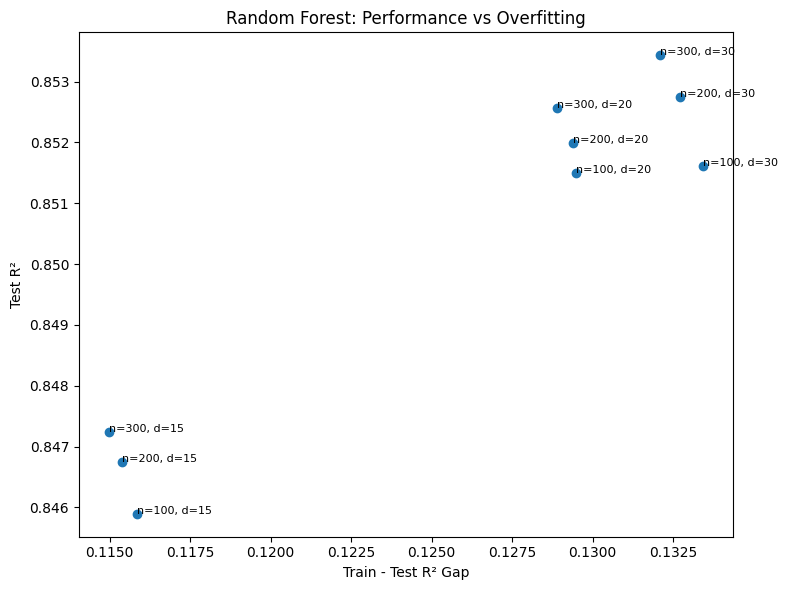

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

rows = [
    {"n": 100, "depth": 15, "RMSE": 0.19605963496778536, "Train_R2": 0.9617436452948762, "Test_R2": 0.8458933988563619},
    {"n": 200, "depth": 15, "RMSE": 0.19552080986129922, "Train_R2": 0.9621211440540646, "Test_R2": 0.8467392884486185},
    {"n": 300, "depth": 15, "RMSE": 0.19520410805642127, "Train_R2": 0.9622043514738852, "Test_R2": 0.8472353853445621},
    
    {"n": 100, "depth": 20, "RMSE": 0.19246035246768992, "Train_R2": 0.9809914149351084, "Test_R2": 0.8514996708419607},
    {"n": 200, "depth": 20, "RMSE": 0.19213988800627485, "Train_R2": 0.9813853082906513, "Test_R2": 0.851993792953494},
    {"n": 300, "depth": 20, "RMSE": 0.19176302636526477, "Train_R2": 0.9814691379235904, "Test_R2": 0.8525738199486064},
    
    {"n": 100, "depth": 30, "RMSE": 0.19239012876357184, "Train_R2": 0.9850509936618062, "Test_R2": 0.851608018774895},
    {"n": 200, "depth": 30, "RMSE": 0.19164769101338258, "Train_R2": 0.9854615361205898, "Test_R2": 0.8527511047707697},
    {"n": 300, "depth": 30, "RMSE": 0.19120240006464154, "Train_R2": 0.98552709162058, "Test_R2": 0.8534345716678774},
]

df = pd.DataFrame(rows)

# Create the overfitting gap
df["Gap"] = df["Train_R2"] - df["Test_R2"]

# Print table
print(df.round(4))

# Scatter plot: overfitting vs performance
plt.figure(figsize=(8, 6))
plt.scatter(df["Gap"], df["Test_R2"])

for _, row in df.iterrows():
    plt.annotate(
        f"n={int(row['n'])}, d={int(row['depth'])}",
        (row["Gap"], row["Test_R2"]),
        fontsize=8
    )

plt.xlabel("Train - Test R² Gap")
plt.ylabel("Test R²")
plt.title("Random Forest: Performance vs Overfitting")
plt.tight_layout()
plt.show()

XGBoost tuning based on n_estimators, max_depth, and learning_rate.

In [ ]:
for depth in [3, 4, 6, 8]:
    for lr in [0.03, 0.05, 0.1]:
        for n in [200, 300, 500]:
            model = xgb.XGBRegressor(
                n_estimators=n,
                max_depth=depth,
                learning_rate=lr,
                subsample=0.8,
                colsample_bytree=0.8,
                random_state=42,
                n_jobs=-1
            )

            model.fit(X_train_xgb, y_train)
            y_pred = model.predict(X_test_xgb)
            y_train_pred = model.predict(X_train_xgb)

            rmse = np.sqrt(mean_squared_error(y_test, y_pred))
            r2 = r2_score(y_test, y_pred)
            train_r2 = r2_score(y_train, y_train_pred)

            gap = train_r2 - r2

            print(f"n={n}, depth={depth}, lr={lr}")
            print("Train R2:", train_r2)
            print("Test  R2:", r2)
            print("RMSE:", rmse)
            print("Gap:", gap)
            print("---------")

n=200, depth=3, lr=0.03
Train R2: 0.8636811586607529
Test  R2: 0.8191426319131181
RMSE: 0.21239567643831841
Gap: 0.04453852674763481
---------
n=300, depth=3, lr=0.03
Train R2: 0.8736756739543279
Test  R2: 0.8272897538198666
RMSE: 0.20755663460535262
Gap: 0.0463859201344613
---------
n=500, depth=3, lr=0.03
Train R2: 0.8836583399103483
Test  R2: 0.8375132769343838
RMSE: 0.20131980856765913
Gap: 0.046145062975964435
---------
n=200, depth=3, lr=0.05
Train R2: 0.8753075290716277
Test  R2: 0.8290779592942434
RMSE: 0.2064793400130125
Gap: 0.04622956977738424
---------
n=300, depth=3, lr=0.05
Train R2: 0.8836192889809708
Test  R2: 0.8391590118082171
RMSE: 0.2002976873929222
Gap: 0.04446027717275369
---------
n=500, depth=3, lr=0.05
Train R2: 0.893539911233405
Test  R2: 0.8497298518786256
RMSE: 0.19360382168983606
Gap: 0.04381005935477944
---------
n=200, depth=3, lr=0.1
Train R2: 0.8889665811019526
Test  R2: 0.8436996469566604
RMSE: 0.1974501864459632
Gap: 0.04526693414529215
---------
n=30

Checking overfitting

      n  depth    lr  Train_R2  Test_R2     Gap
0   200      3  0.03    0.8637   0.8191  0.0446
1   300      3  0.03    0.8737   0.8273  0.0464
2   500      3  0.03    0.8837   0.8375  0.0462
3   200      3  0.05    0.8753   0.8291  0.0462
4   300      3  0.05    0.8836   0.8392  0.0444
5   500      3  0.05    0.8935   0.8497  0.0438
6   200      3  0.10    0.8890   0.8437  0.0453
7   300      3  0.10    0.8960   0.8512  0.0448
8   500      3  0.10    0.9050   0.8613  0.0437
9   200      4  0.05    0.8890   0.8416  0.0474
10  300      4  0.05    0.8978   0.8510  0.0468
11  500      4  0.05    0.9084   0.8612  0.0472
12  200      6  0.05    0.9161   0.8619  0.0542
13  300      6  0.05    0.9261   0.8700  0.0561
14  500      6  0.05    0.9393   0.8783  0.0610
15  200      8  0.05    0.9448   0.8776  0.0672
16  300      8  0.05    0.9551   0.8834  0.0717
17  500      8  0.05    0.9678   0.8887  0.0791


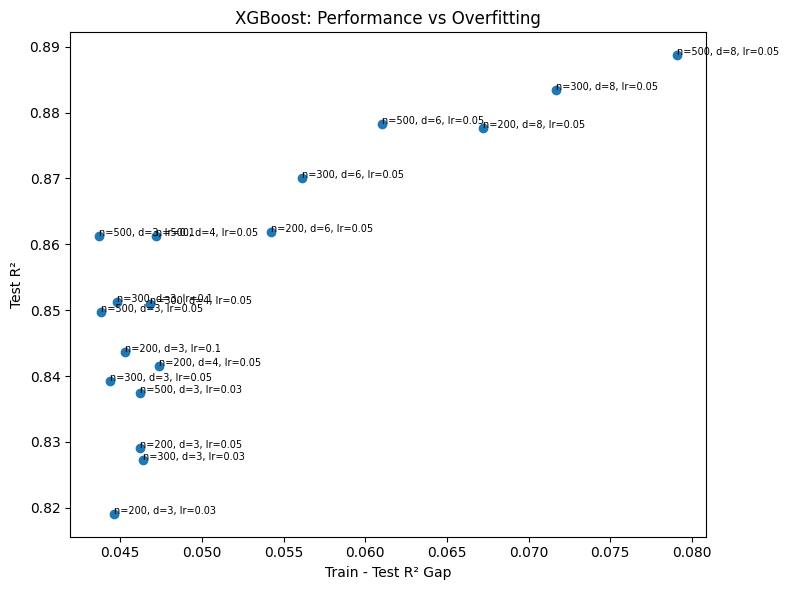

In [ ]:
rows = [
{"n":200,"depth":3,"lr":0.03,"Train_R2":0.8637,"Test_R2":0.8191},
{"n":300,"depth":3,"lr":0.03,"Train_R2":0.8737,"Test_R2":0.8273},
{"n":500,"depth":3,"lr":0.03,"Train_R2":0.8837,"Test_R2":0.8375},

{"n":200,"depth":3,"lr":0.05,"Train_R2":0.8753,"Test_R2":0.8291},
{"n":300,"depth":3,"lr":0.05,"Train_R2":0.8836,"Test_R2":0.8392},
{"n":500,"depth":3,"lr":0.05,"Train_R2":0.8935,"Test_R2":0.8497},

{"n":200,"depth":3,"lr":0.1,"Train_R2":0.8890,"Test_R2":0.8437},
{"n":300,"depth":3,"lr":0.1,"Train_R2":0.8960,"Test_R2":0.8512},
{"n":500,"depth":3,"lr":0.1,"Train_R2":0.9050,"Test_R2":0.8613},

{"n":200,"depth":4,"lr":0.05,"Train_R2":0.8890,"Test_R2":0.8416},
{"n":300,"depth":4,"lr":0.05,"Train_R2":0.8978,"Test_R2":0.8510},
{"n":500,"depth":4,"lr":0.05,"Train_R2":0.9084,"Test_R2":0.8612},

{"n":200,"depth":6,"lr":0.05,"Train_R2":0.9161,"Test_R2":0.8619},
{"n":300,"depth":6,"lr":0.05,"Train_R2":0.9261,"Test_R2":0.8700},
{"n":500,"depth":6,"lr":0.05,"Train_R2":0.9393,"Test_R2":0.8783},

{"n":200,"depth":8,"lr":0.05,"Train_R2":0.9448,"Test_R2":0.8776},
{"n":300,"depth":8,"lr":0.05,"Train_R2":0.9551,"Test_R2":0.8834},
{"n":500,"depth":8,"lr":0.05,"Train_R2":0.9678,"Test_R2":0.8887},
]

df = pd.DataFrame(rows)

# gap
df["Gap"] = df["Train_R2"] - df["Test_R2"]

print(df.round(4))

plt.figure(figsize=(8,6))
plt.scatter(df["Gap"], df["Test_R2"])

for _, row in df.iterrows():
    plt.annotate(
        f"n={int(row['n'])}, d={int(row['depth'])}, lr={row['lr']}",
        (row["Gap"], row["Test_R2"]),
        fontsize=7
    )

plt.xlabel("Train - Test R² Gap")
plt.ylabel("Test R²")
plt.title("XGBoost: Performance vs Overfitting")

plt.tight_layout()
plt.show()

In [ ]:
# end - Jenny Li